# Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

import sys
sys.path.append('..')
from pipeline import (
    RF_FEATURES, SVM_FEATURES, SVM_SCALE_COLS,
    RF_MINMAX_COLS, RF_STANDARD_COLS,
    filter_port, decode_attack_labels, ATTACK_LABELS,
)

# Load and Inspect

In [2]:
df = pd.read_csv('../ryu-controller/traffic_log.csv')

# keep attack traffic only
df = df[df['Traffic'] == 'Attack'].copy()

print(df['Attack_type'].value_counts())
print(f'Total attack samples: {len(df)}')

Attack_type
Unknown    4709
Name: count, dtype: int64
Total attack samples: 4709


C:\Users\moulo\AppData\Local\Temp\ipykernel_25408\1736932917.py:1: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../ryu-controller/traffic_log.csv')


In [ ]:
import json

# load monitor's attack window log
with open('../ryu-controller/attack_log.json') as f:
    monitor_log = json.load(f)

# load run_attack.py process log
with open('../ryu-controller/run_attack_log.json') as f:
    attack_log = json.load(f)

# for each monitor window, find which attack was running at that time
for window in monitor_log:
    for attack in attack_log:
        if window['start'] >= attack['start'] and window['end'] <= attack['end']:
            mask = (
                (df['Timestamp'] >= window['start']) &
                (df['Timestamp'] <= window['end']) &
                (df['Traffic'] == 'Attack')
            )
            df.loc[mask, 'Attack_type'] = attack['attack_type']
            break

ICMP_flood: 0 rows labeled
SYN_flood: 0 rows labeled
UDP_flood: 0 rows labeled
HTTP_flood: 0 rows labeled
LAND_attack: 0 rows labeled
SLOWLORIS: 4709 rows labeled


In [5]:
print('CSV timestamp range:')
print(df[df['Traffic'] == 'Attack']['Timestamp'].min())
print(df[df['Traffic'] == 'Attack']['Timestamp'].max())

print('\nAttack log ranges:')
for entry in attack_log:
    print(f"{entry['attack_type']}: {entry['start']} → {entry['end']}")

CSV timestamp range:
1776068173.646802
1776068223.865055

Attack log ranges:
ICMP_flood: 1776067420.8144014 → 1776067540.9172924
SYN_flood: 1776067570.948224 → 1776067691.0456438
UDP_flood: 1776067721.0508115 → 1776067841.1495702
HTTP_flood: 1776067871.1651406 → 1776067991.2661989
LAND_attack: 1776068021.286669 → 1776068141.3143504
SLOWLORIS: 1776068171.3255193 → 1776068291.3428433


# Correlation

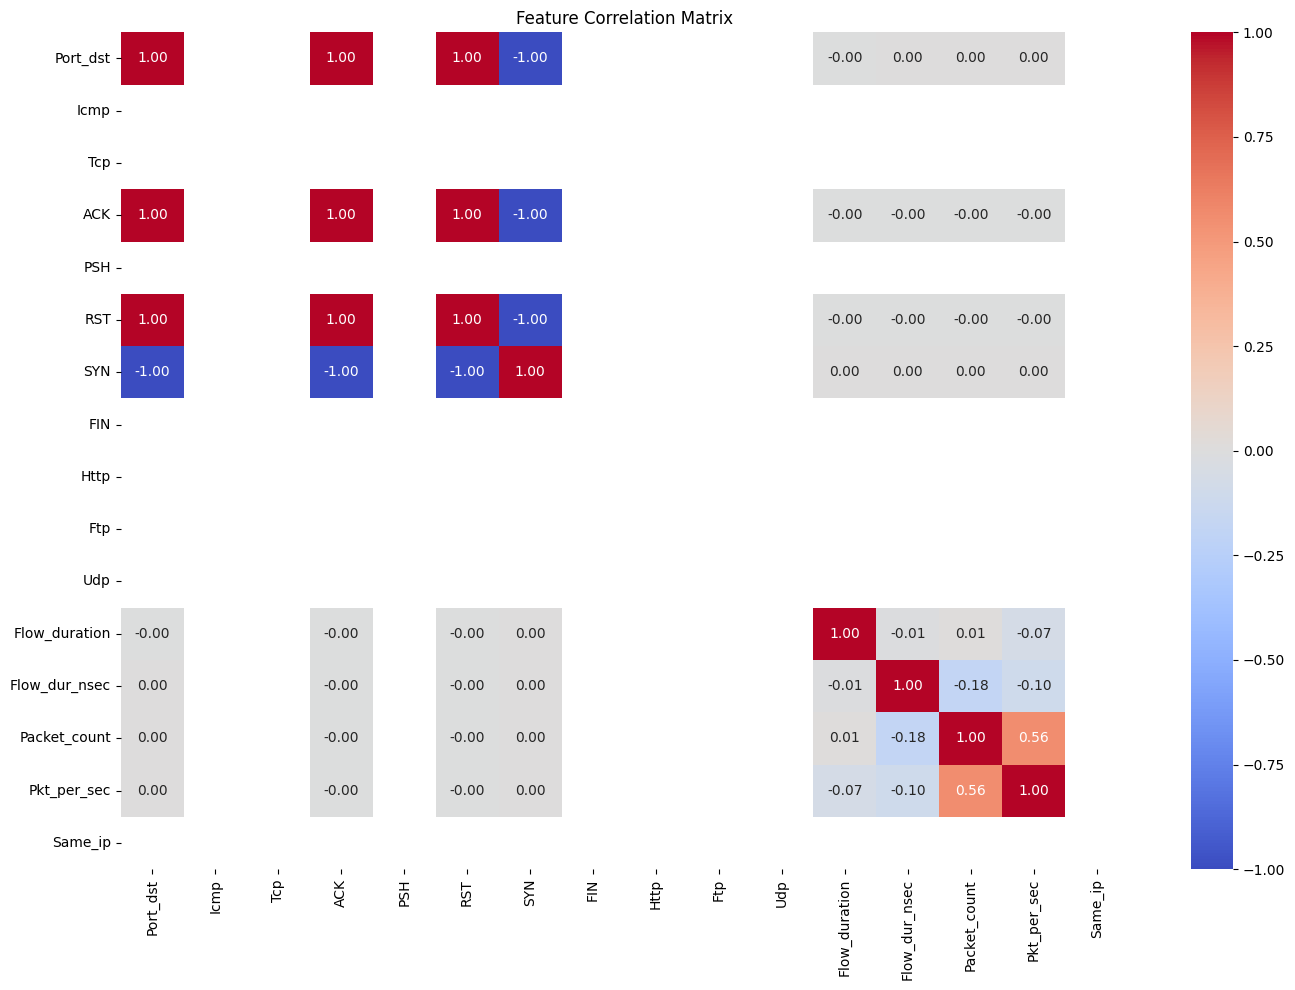

Highly correlated pairs (>0.9):
  Port_dst <-> ACK: 1.000
  Port_dst <-> RST: 1.000
  Port_dst <-> SYN: -1.000
  ACK <-> RST: 1.000
  ACK <-> SYN: -1.000
  RST <-> SYN: -1.000


In [7]:
numeric_cols = RF_FEATURES

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# highly correlated pairs (threshold 0.9)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print('Highly correlated pairs (>0.9):')
for a, b, v in high_corr:
    print(f'  {a} <-> {b}: {v:.3f}')

# Drop redundant features based on correlation

In [8]:
# updated after inspecting the heatmap
COLS_TO_DROP = ['Flow_dur_nsec']  # example — update based on your output

FINAL_FEATURES = [f for f in RF_FEATURES if f not in COLS_TO_DROP]
print('Final features:', FINAL_FEATURES)

Final features: ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Udp', 'Flow_duration', 'Packet_count', 'Pkt_per_sec', 'Same_ip']


# Label encoding and train-test split

In [9]:
le = LabelEncoder()

# encode attack types to integers matching ATTACK_LABELS
label_map = {v: k for k, v in ATTACK_LABELS.items()}

df['label'] = df['Attack_type'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

X = df[FINAL_FEATURES].copy()
X['Port_dst'] = X['Port_dst'].apply(filter_port)
y = df['label']

print('Label distribution:')
print(y.value_counts())

Label distribution:
label
0    4709
Name: count, dtype: int64


# RF Preprocess

In [10]:
X_rf = X.copy()

mm = MinMaxScaler()
std = StandardScaler()

# only scale cols that are still present after dropping
mm_cols  = [c for c in RF_MINMAX_COLS  if c in X_rf.columns]
std_cols = [c for c in RF_STANDARD_COLS if c in X_rf.columns]

X_rf[mm_cols]  = mm.fit_transform(X_rf[mm_cols])
X_rf[std_cols] = std.fit_transform(X_rf[std_cols])

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)

# SVM Prepeocess

In [11]:
X_svm = X.copy()

svm_std = StandardScaler()
svm_cols = [c for c in SVM_SCALE_COLS if c in X_svm.columns]
X_svm[svm_cols] = svm_std.fit_transform(X_svm[svm_cols])

X_train_svm, X_test_svm, _, _ = train_test_split(
    X_svm, y, test_size=0.2, random_state=42, stratify=y
)

# Train RF

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

print('='*10)
print('Random Forest')
print('='*10)
print(classification_report(y_test, y_pred_rf,
      target_names=list(ATTACK_LABELS.values())))

Random Forest


ValueError: Number of classes, 1, does not match size of target_names, 6. Try specifying the labels parameter

# Train SVM

In [ ]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_svm, y_train)
y_pred_svm = svm.predict(X_test_svm)

print('='*10)
print('SVM')
print('='*10)
print(classification_report(y_test, y_pred_svm,
      target_names=list(ATTACK_LABELS.values())))

# Confusion Matrix

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = list(ATTACK_LABELS.values())

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_svm],
    ['Random Forest', 'SVM']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Comparison between RF and SVM results

In [ ]:
metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_rf, average='weighted'),
                  precision_score(y_test, y_pred_svm, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_rf, average='weighted'),
                  recall_score(y_test, y_pred_svm, average='weighted')],
    'F1':        [f1_score(y_test, y_pred_rf, average='weighted'),
                  f1_score(y_test, y_pred_svm, average='weighted')],
}

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_rf  = ax.bar(x - width/2, [v[0] for v in metrics.values()],
                  width, label='Random Forest', color='steelblue')
bars_svm = ax.bar(x + width/2, [v[1] for v in metrics.values()],
                  width, label='SVM', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('RF vs SVM — Performance Comparison')
ax.legend()

# labels
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save models

In [ ]:
with open('../ryu-controller/RF.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../ryu-controller/SVM.pkl', 'wb') as f:
    pickle.dump(svm, f)

print('Models saved.')
print(f'\nRF  accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'SVM accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'\nBetter model: {"RF" if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_svm) else "SVM"}')

### Saving the models as `onnx` files for compatibility with RYU on python 3.8

In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

n_features = len(FINAL_FEATURES)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

# RF
rf_onnx = convert_sklearn(rf, initial_types=initial_type)
with open('../ryu-controller/RF.onnx', 'wb') as f:
    f.write(rf_onnx.SerializeToString())

# SVM
svm_onnx = convert_sklearn(svm, initial_types=initial_type)
with open('../ryu-controller/SVM.onnx', 'wb') as f:
    f.write(svm_onnx.SerializeToString())

print('RF.onnx and SVM.onnx saved.')